# Oil Spill Simulation: from Satellite Detection to Drift Forecast

Research on oil spills usually treats detection and simulation separately: remote sensing and
machine learning find the slicks, and oceanographic models simulate their drift. In a real
response the two have to work together, because a satellite detection is only a snapshot while
responders need to know where the oil goes next.

This notebook connects the two. An oil slick detected by
[SkyTruth Cerulean](https://cerulean.skytruth.org) off the Norwegian coast on 11 March 2025 is
seeded into the OpenOil model of [OpenDrift](https://opendrift.github.io), which forecasts its
drift and weathering over 24 hours using HYCOM ocean currents and NOAA GFS winds. Every step
uses open data and open-source tools.

1. Detection: query the slick from the Cerulean API
2. Preprocessing: prepare the slick polygon for seeding
3. Simulation setup: forcing data, oil type and seeding
4. Run
5. Results: trajectory, oil budget and animations

In [1]:
import json
import logging
from datetime import datetime, timedelta
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

from opendrift.models.openoil import OpenOil
from opendrift.readers import reader_netCDF_CF_generic

DATA = Path("data")
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

## 1. Detection (SkyTruth Cerulean)

Cerulean is SkyTruth's global system for tracking ocean oil pollution. It detects oil slicks in
satellite radar imagery with machine learning and identifies nearby vessels and offshore
infrastructure that may be responsible. The detections are available through an OGC-compliant
API. The query below returns the slicks detected in the study area on 11 March 2025.

In [2]:
CERULEAN_API = "https://api.cerulean.skytruth.org/collections/public.slick_plus/items"
query = {
    "limit": 100,
    "bbox": "4.2,60.2,4.9,60.5",                                  # lon/lat box off the Norwegian coast
    "datetime": "2025-03-11T00:00:00Z/2025-03-12T00:00:00Z",
}
detections = requests.get(CERULEAN_API, params=query, timeout=60).json()
slicks = gpd.GeoDataFrame.from_features(detections["features"], crs="EPSG:4326")
slicks[["id", "slick_timestamp", "area"]]

,id,slick_timestamp,area
0,3866470,2025-03-11T17:27:27,2.608499e+06


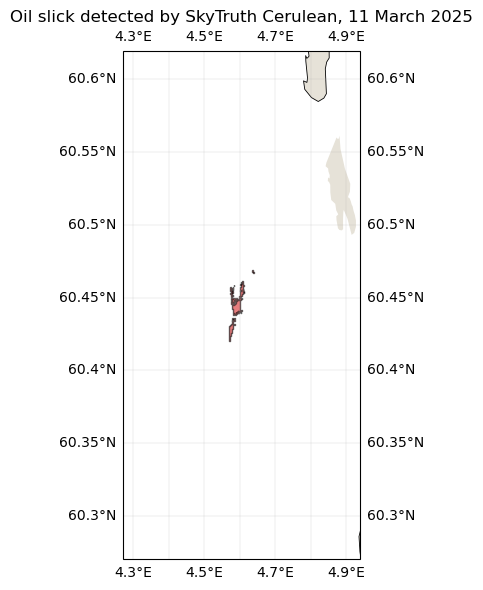

In [3]:
def plot_slicks(gdf, pad=0.3):
    """Plot slick polygons over a coastline map."""
    minx, miny, maxx, maxy = gdf.total_bounds
    ax = plt.figure(figsize=(7, 6)).add_subplot(projection=ccrs.Mercator())
    ax.set_extent([minx - pad, maxx + pad, miny - pad / 2, maxy + pad / 2], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#e6e2d8")
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gdf.plot(ax=ax, transform=ccrs.PlateCarree(), color="#d62728", alpha=0.6, edgecolor="black")
    return ax


ax = plot_slicks(slicks)
ax.set_title("Oil slick detected by SkyTruth Cerulean, 11 March 2025")
plt.show()

## 2. Slick Preprocessing

The detection was downloaded from the Cerulean web app as GeoJSON
(`data/slick_norway_2025-03-11.geojson`). OpenDrift seeds from a single Polygon, so the first
polygon of the MultiPolygon is used. The file carries no time or oil type: the detection time is
taken from the file name, and GENERIC DIESEL from the NOAA ADIOS oil database is used as a
representative light oil. The slick is seeded with 10,000 Lagrangian elements.

In [4]:
number = 10000                                   # Lagrangian elements
oil_type = "GENERIC DIESEL"
seed_time = datetime(2025, 3, 11, 17, 27, 52)    # detection time, from the file name
timestep = timedelta(minutes=10)
timestep_output = timedelta(minutes=60)
duration = timedelta(hours=24)

with open(DATA / "slick_norway_2025-03-11.geojson") as f:
    slick = json.load(f)["features"][0]
assert slick["geometry"]["type"] == "MultiPolygon"

seed_feature = {
    "type": "Feature",
    "geometry": {"type": "Polygon", "coordinates": slick["geometry"]["coordinates"][0]},
    "properties": {
        "time": seed_time.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "number": number,
        "oil_type": oil_type,
    },
}

## 3. Simulation Setup

OpenOil is driven by two environmental datasets:

- **HYCOM** ocean surface currents, a local subset covering 11 to 15 March 2025
  (`data/hycom_norway_2025-03.nc4`)
- **NOAA GFS** 10 m winds, read directly from the PacIOOS THREDDS server

OpenDrift maps the eastward and northward components to its own velocity variables. Variables
that neither dataset provides, such as waves, fall back to OpenDrift's default values.

In [5]:
o = OpenOil(loglevel=30)                         # show warnings only
# the interpolator warns at every step for land (NaN) points next to the coast
logging.getLogger("opendrift.readers.interpolation.interpolators").setLevel(logging.ERROR)

reader_hycom = reader_netCDF_CF_generic.Reader(str(DATA / "hycom_norway_2025-03.nc4"))
reader_noaa = reader_netCDF_CF_generic.Reader(
    "https://pae-paha.pacioos.hawaii.edu/thredds/dodsC/ncep_global/NCEP_Global_Atmospheric_Model_best.ncd"
)
o.add_reader([reader_hycom, reader_noaa])

for name, reader in [("HYCOM currents", reader_hycom), ("NOAA GFS wind", reader_noaa)]:
    print(f"{name:15s} {reader.start_time} to {reader.end_time}")
if seed_time < reader_hycom.start_time or seed_time + duration > reader_hycom.end_time:
    print("WARNING: the simulation period is not fully covered by the HYCOM data")

o.seed_from_geojson(json.dumps(seed_feature))

HYCOM currents  2025-03-11 12:00:00 to 2025-03-15 12:00:00
NOAA GFS wind   2022-12-01 12:00:00 to 2026-09-28 15:00:00


## 4. Run

24 hours with a 10-minute time step, writing the state every hour.

In [6]:
o.run(
    end_time=seed_time + duration,
    time_step=timestep.total_seconds(),
    time_step_output=timestep_output.total_seconds(),
    outfile=str(RESULTS / "oil_simulation.nc"),
);

17:47:47 WARNING opendrift.export.io_netcdf:27: Deleting existing results\oil_simulation.nc


## 5. Results

### Trajectory and vertical distribution

17:48:27 WARNING opendrift:2437: Plotting fast. This will make your plots less accurate.


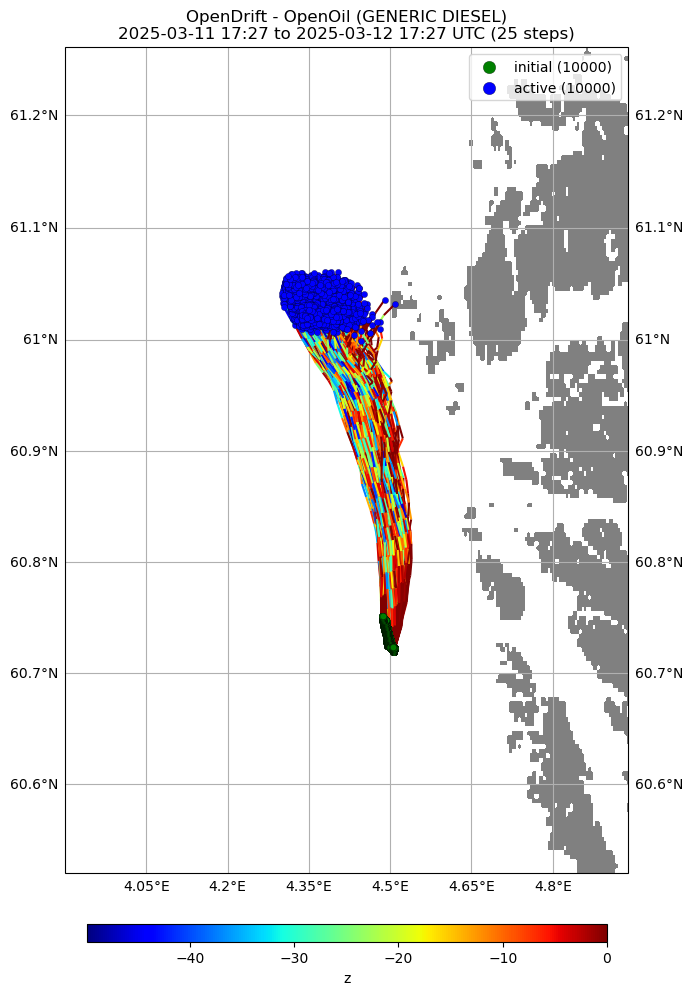

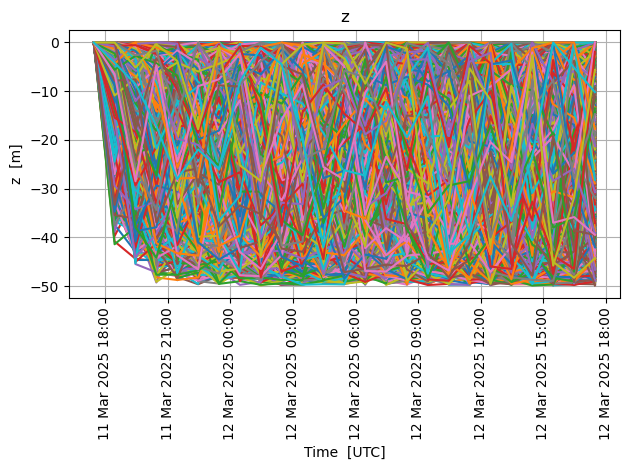

In [7]:
o.plot(linecolor="z", fast=True)
o.plot_property("z")

### Oil budget

How the oil mass is split between the surface, the water column and evaporation over time,
together with the emulsion properties and the wind and current speeds.

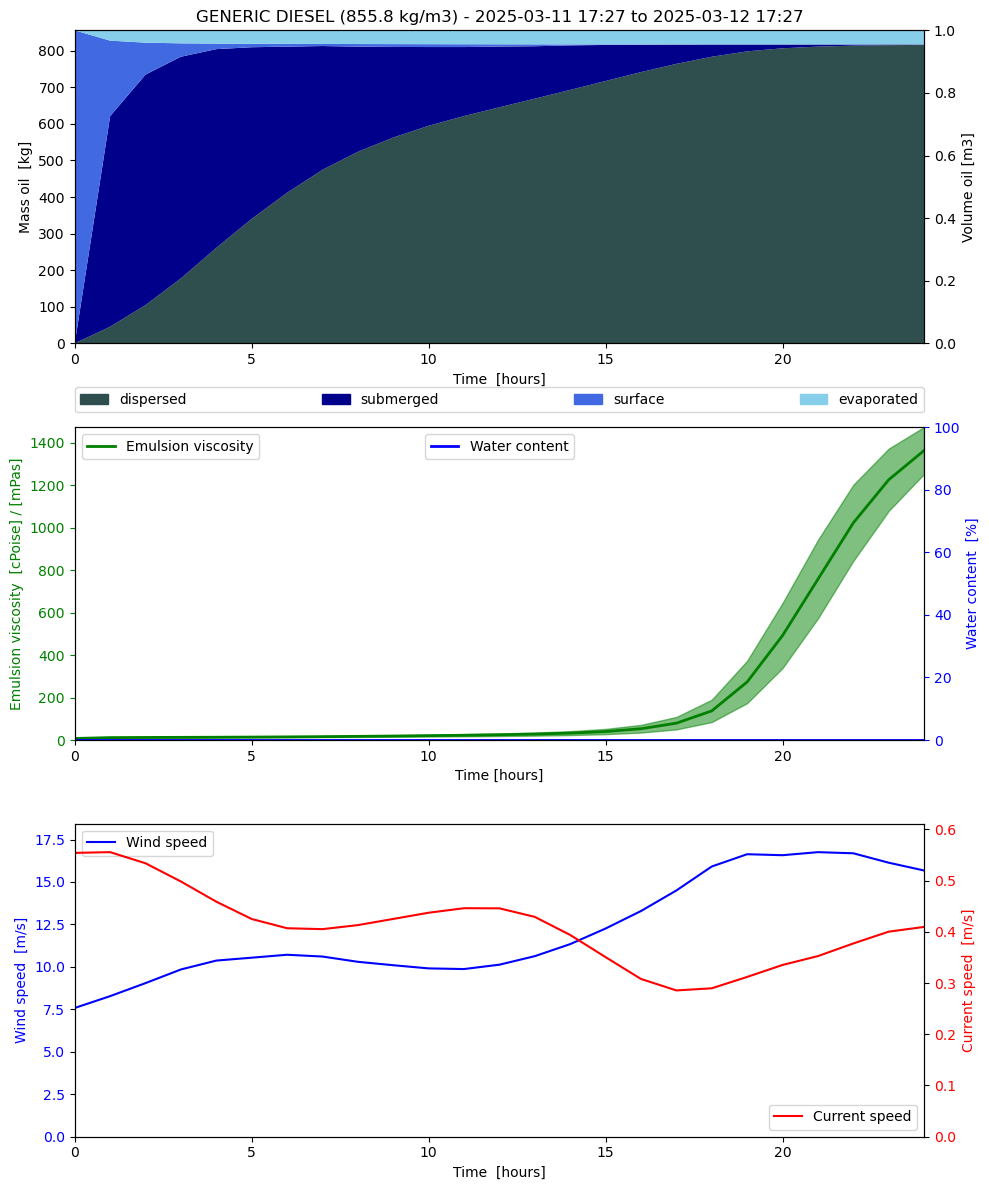

In [8]:
o.plot_oil_budget()

### Animations

Saved to `results/`: oil film thickness, trajectory, vertical distribution, and the slick drifting
over the current and wind fields.

In [9]:
unitfactor = 1e6                                 # film thickness in micrometres
o.animation(color="oil_film_thickness", fast=True, vmin=1e-7 * unitfactor, vmax=1e-4 * unitfactor,
            unitfactor=unitfactor, surface_only=True, filename=str(RESULTS / "oil_film_thickness.gif"))
o.animation(fast=True, filename=str(RESULTS / "oil_trajectory.gif"))
o.animate_vertical_distribution(filename=str(RESULTS / "oil_vertical_distribution.gif"))
o.animation(fast=True, background=["x_sea_water_velocity", "y_sea_water_velocity"],
            filename=str(RESULTS / "currents.gif"))
o.animation(fast=True, background=["x_wind", "y_wind"], filename=str(RESULTS / "wind.gif"))

17:51:51 WARNING opendrift:2437: Plotting fast. This will make your plots less accurate.


17:52:12 WARNING opendrift:2437: Plotting fast. This will make your plots less accurate.


17:52:44 WARNING opendrift:2437: Plotting fast. This will make your plots less accurate.


17:53:05 WARNING opendrift:2437: Plotting fast. This will make your plots less accurate.


In [10]:
# still images for the README
o.plot(linecolor="z", fast=True, filename=str(RESULTS / "trajectory.png"))
o.plot_oil_budget(filename=str(RESULTS / "oil_budget.png"))
plt.close("all")

17:53:36 WARNING opendrift:2437: Plotting fast. This will make your plots less accurate.
